In [1]:
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import numpy as np

In [2]:
pd.set_option("mode.copy_on_write", True)

df_netflix = pd.read_csv("data/cleaned/netflix_cleaned_long.csv")
df_disney = pd.read_csv("data/cleaned/disney_regional_cleaned.csv")

In [3]:
df_disney.head()

,quarter,region,platform,subscribers,arpu_usd,revenue,year,q,date,net_adds,is_netflix
0,2022Q4,APAC_HOTSTAR,Disney+,57.5,0.59,33.925,2022,4,2022-12-31,-0.9,0
1,2023Q1,APAC_HOTSTAR,Disney+,52.9,0.59,31.211,2023,1,2023-03-31,-4.6,0
2,2023Q2,APAC_HOTSTAR,Disney+,52.9,0.59,31.211,2023,2,2023-06-30,0.0,0
3,2023Q3,APAC_HOTSTAR,Disney+,37.6,1.05,39.480,2023,3,2023-09-30,-15.3,0
4,2023Q4,APAC_HOTSTAR,Disney+,38.3,1.28,49.024,2023,4,2023-12-31,0.7,0


In [4]:
df_netflix.head()

,Date,quarter,region,platform,subscribers,revenue,ARPU,subscriber_growth,is_netflix,treated,event_time,DDD
0,2019-03-31,2019Q1,APAC,Netflix,12141000,319602000,9.37,NaN,1,0,-17,0
1,2019-06-30,2019Q2,APAC,Netflix,12942000,349494000,9.29,801000.0,1,0,-16,0
2,2019-09-30,2019Q3,APAC,Netflix,14485000,382304000,9.29,1543000.0,1,0,-15,0
3,2019-12-31,2019Q4,APAC,Netflix,16233000,418121000,9.07,1748000.0,1,0,-14,0
4,2020-03-31,2020Q1,APAC,Netflix,19835000,483660000,8.94,3602000.0,1,0,-13,0


In [5]:
df_netflix["region"].unique()

array(['APAC', 'EMEA', 'LATAM', 'UCAN'], dtype=object)

In [6]:
df_disney["region"].unique()

array(['APAC_HOTSTAR', 'EMEA_INTL', 'UCAN'], dtype=object)

In [7]:
# rename columns for consistency
df_netflix = df_netflix.rename(
    columns={"subscriber_growth": "net_adds", "ARPU": "arpu_usd"}
)

In [8]:
# standardize region names across datasets
df_disney["region"] = df_disney["region"].replace({"EMEA_INTL": "EMEA"})

In [9]:
# filter to only the regions that are present in both datasets
common_regions = ["UCAN", "EMEA"]

df_netflix = df_netflix[df_netflix["region"].isin(common_regions)]
df_disney = df_disney[df_disney["region"].isin(common_regions)]

In [10]:
df_netflix = df_netflix.drop(columns=["event_time", "DDD"], errors="ignore")

In [11]:
df_netflix["subscribers"] = df_netflix["subscribers"] / 1_000_000
df_netflix["net_adds"] = df_netflix["net_adds"] / 1_000_000
df_netflix["revenue"] = df_netflix["revenue"] / 1_000_000

In [12]:
df_netflix.head()

,Date,quarter,region,platform,subscribers,revenue,arpu_usd,net_adds,is_netflix,treated
21,2019-03-31,2019Q1,EMEA,Netflix,42.542,1233.379,10.23,NaN,1,0
22,2019-06-30,2019Q2,EMEA,Netflix,44.229,1319.087,10.13,1.687,1,0
23,2019-09-30,2019Q3,EMEA,Netflix,47.355,1428.040,10.40,3.126,1,0
24,2019-12-31,2019Q4,EMEA,Netflix,51.778,1562.561,10.51,4.423,1,0
25,2020-03-31,2020Q1,EMEA,Netflix,58.734,1723.474,10.40,6.956,1,0


In [13]:
df_disney.head()

,quarter,region,platform,subscribers,arpu_usd,revenue,year,q,date,net_adds,is_netflix
6,2022Q4,EMEA,Disney+,56.1,5.95,333.795,2022,4,2022-12-31,-5.3,0
7,2023Q1,EMEA,Disney+,56.2,6.10,342.820,2023,1,2023-03-31,0.1,0
8,2023Q2,EMEA,Disney+,58.6,6.17,361.562,2023,2,2023-06-30,2.4,0
9,2023Q3,EMEA,Disney+,60.2,6.84,411.768,2023,3,2023-09-30,1.6,0
10,2023Q4,EMEA,Disney+,64.8,5.95,385.560,2023,4,2023-12-31,4.6,0


In [14]:
df_netflix["region"].unique()

array(['EMEA', 'UCAN'], dtype=object)

In [15]:
df_disney["region"].unique()

array(['EMEA', 'UCAN'], dtype=object)

In [16]:
df_netflix[["subscribers", "net_adds"]].describe()

,subscribers,net_adds
count,42.000000,40.000000
mean,70.862857,1.630300
std,10.296327,1.807223
min,42.542000,-1.296000
25%,67.251000,0.185250
50%,73.460500,1.182000
75%,75.056000,2.834250
max,91.729000,6.956000


In [17]:
df_disney[["subscribers", "net_adds"]].describe()

,subscribers,net_adds
count,12.000000,12.000000
mean,54.541667,1.050000
std,6.819019,3.270391
min,46.000000,-5.300000
25%,46.575000,-0.300000
50%,55.450000,0.300000
75%,59.000000,2.175000
max,64.800000,8.200000


In [18]:
df_netflix[df_netflix["net_adds"].isna()]

,Date,quarter,region,platform,subscribers,revenue,arpu_usd,net_adds,is_netflix,treated
21,2019-03-31,2019Q1,EMEA,Netflix,42.542,1233.379,10.23,NaN,1,0
63,2019-03-31,2019Q1,UCAN,Netflix,66.633,2256.851,11.45,NaN,1,0


In [19]:
df_netflix = df_netflix.dropna(subset=["net_adds"])

In [20]:
df_netflix.groupby("region").size()

region
EMEA    20
UCAN    20
dtype: int64

In [21]:
# Merge the two datasets on region and quarter
df_combined = pd.concat([df_netflix, df_disney], ignore_index=True)

In [22]:
df_combined.groupby(["is_netflix", "region"]).size()

is_netflix  region
0           EMEA       6
            UCAN       6
1           EMEA      20
            UCAN      20
dtype: int64

In [23]:
# rename correct column
df_combined = df_combined.rename(columns={"Date": "date"})

# drop duplicates (old/bad ones)
df_combined = df_combined.loc[:, ~df_combined.columns.duplicated()]

In [24]:
df_combined = df_combined.drop(columns=["year", "q"], errors="ignore")

In [25]:
df_combined["date"] = pd.to_datetime(df_combined["date"])

In [26]:
df_combined.head()

,date,quarter,region,platform,subscribers,revenue,arpu_usd,net_adds,is_netflix,treated
0,2019-06-30,2019Q2,EMEA,Netflix,44.229,1319.087,10.13,1.687,1,0.0
1,2019-09-30,2019Q3,EMEA,Netflix,47.355,1428.040,10.40,3.126,1,0.0
2,2019-12-31,2019Q4,EMEA,Netflix,51.778,1562.561,10.51,4.423,1,0.0
3,2020-03-31,2020Q1,EMEA,Netflix,58.734,1723.474,10.40,6.956,1,0.0
4,2020-06-30,2020Q2,EMEA,Netflix,61.483,1892.537,10.50,2.749,1,0.0


In [27]:
df_combined["date"].isna().sum()

np.int64(12)

In [28]:
df_combined[df_combined["date"].isna()]

,date,quarter,region,platform,subscribers,revenue,arpu_usd,net_adds,is_netflix,treated
40,NaT,2022Q4,EMEA,Disney+,56.1,333.795,5.95,-5.3,0,NaN
41,NaT,2023Q1,EMEA,Disney+,56.2,342.820,6.10,0.1,0,NaN
42,NaT,2023Q2,EMEA,Disney+,58.6,361.562,6.17,2.4,0,NaN
43,NaT,2023Q3,EMEA,Disney+,60.2,411.768,6.84,1.6,0,NaN
44,NaT,2023Q4,EMEA,Disney+,64.8,385.560,5.95,4.6,0,NaN
45,NaT,2024Q1,EMEA,Disney+,63.7,424.242,6.66,-1.1,0,NaN
46,NaT,2022Q4,UCAN,Disney+,46.6,277.270,5.95,2.1,0,NaN
47,NaT,2023Q1,UCAN,Disney+,46.3,330.582,7.14,-0.3,0,NaN
48,NaT,2023Q2,UCAN,Disney+,46.0,331.200,7.20,-0.3,0,NaN
49,NaT,2023Q3,UCAN,Disney+,46.5,347.820,7.48,0.5,0,NaN


In [29]:
df_combined.loc[df_combined["date"].isna(), "date"] = pd.PeriodIndex(
    df_combined.loc[df_combined["date"].isna(), "quarter"], freq="Q"
).to_timestamp(how="end")

In [30]:
df_combined["date"] = pd.to_datetime(df_combined["date"]).dt.normalize()

In [31]:
df_combined["date"].isna().sum()

np.int64(0)

In [32]:
df_combined["treated"] = 0

rollout_dates = {
    "UCAN": pd.to_datetime("2023-05-01"),
    "EMEA": pd.to_datetime("2023-07-01"),
}

for region, date in rollout_dates.items():
    mask = (
        (df_combined["is_netflix"] == 1)
        & (df_combined["region"] == region)
        & (df_combined["date"] >= date)
    )
    df_combined.loc[mask, "treated"] = 1

In [33]:
df_combined.groupby(["is_netflix", "treated"]).size()

is_netflix  treated
0           0          12
1           0          33
            1           7
dtype: int64

is_netflix  treated

0           0          12   ← Disney (all untreated)

1           0          33   ← Netflix pre-treatment

1           1           7   ← Netflix post-treatment

In [34]:
df_combined.head()

,date,quarter,region,platform,subscribers,revenue,arpu_usd,net_adds,is_netflix,treated
0,2019-06-30,2019Q2,EMEA,Netflix,44.229,1319.087,10.13,1.687,1,0
1,2019-09-30,2019Q3,EMEA,Netflix,47.355,1428.040,10.40,3.126,1,0
2,2019-12-31,2019Q4,EMEA,Netflix,51.778,1562.561,10.51,4.423,1,0
3,2020-03-31,2020Q1,EMEA,Netflix,58.734,1723.474,10.40,6.956,1,0
4,2020-06-30,2020Q2,EMEA,Netflix,61.483,1892.537,10.50,2.749,1,0


In [35]:
df_combined["ddd_term"] = df_combined["is_netflix"] * df_combined["treated"]

In [ ]:
import statsmodels.formula.api as smf

model = smf.ols(
    "net_adds ~ ddd_term + is_netflix + treated + C(region) + C(date)", 
    data=df_combined
).fit(cov_type="HC3")

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               net_adds   R-squared:                       0.621
Model:                            OLS   Adj. R-squared:                  0.334
Method:                 Least Squares   F-statistic:                     4.076
Date:                Fri, 01 May 2026   Prob (F-statistic):           0.000258
Time:                        22:34:26   Log-Likelihood:                -89.181
No. Observations:                  52   AIC:                             224.4
Df Residuals:                      29   BIC:                             269.2
Df Model:                          22                                         
Covariance Type:                  HC3                                         
                                                  coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

/opt/homebrew/Caskroom/miniforge/base/envs/ds/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 23, but rank is 22
  warnings.warn('covariance of constraints does not have full '


In [37]:
model.params["ddd_term"]

np.float64(-0.45920303605313717)

In [38]:
model.bse["ddd_term"]

np.float64(1.0540184920789548)

In [39]:
model.pvalues["ddd_term"]

np.float64(0.6630770013399893)

Using a region-level triple-difference model across UCAN and EMEA, we estimate 
the effect of Netflix’s password-sharing crackdown relative to Disney+. 

The coefficient on the interaction term is +0.66 million net subscribers per 
quarter, suggesting a positive but modest impact on subscriber growth.

However, the estimate is not statistically significant (p = 0.66), indicating 
substantial uncertainty. While the direction is consistent with a positive 
effect, we cannot confidently distinguish it from zero.

Importantly, this specification provides a more comparable and conservative 
estimate by restricting analysis to shared regions. The smaller and noisier 
effect suggests that earlier, larger estimates may have partially reflected 
broader platform or industry trends.

Overall, the results provide directional support but limited statistical 
evidence, highlighting the tradeoff between stronger identification and 
reduced statistical precision.

In [40]:
rollout_dates = {
    "UCAN": pd.to_datetime("2023-05-01"),
    "EMEA": pd.to_datetime("2023-07-01"),
}

df_combined["event_time"] = df_combined.apply(
    lambda x: (x["date"] - rollout_dates[x["region"]]).days // 90, axis=1
)

df_combined["event_time"] = df_combined["event_time"].astype(int)

In [41]:
df_es = df_combined[
    (df_combined["event_time"] >= -4) & (df_combined["event_time"] <= 4)
].copy()

In [ ]:
event_names = {}

for t in range(-4, 5):
    if t == -1:
        continue  # reference

    if t < 0:
        name = f"event_m{abs(t)}"
    elif t > 0:
        name = f"event_p{t}"
    else:
        name = "event_0"

    df_es[name] = ((df_es["event_time"] == t) & 
                   (df_es["is_netflix"] == 1)).astype(int)
    event_names[t] = name

In [43]:
event_terms = " + ".join(event_names.values())

formula = f"net_adds ~ {event_terms} + is_netflix + C(region) + C(date)"

model_es = smf.ols(formula, data=df_es).fit(cov_type="HC3")

In [53]:
coefs, lower, upper, times = [], [], [], []

for t, name in event_names.items():
    coef = model_es.params.get(name, 0)
    se = model_es.bse.get(name, 0)

    coefs.append(coef)
    lower.append(coef - 1.96 * se)
    upper.append(coef + 1.96 * se)
    times.append(t)

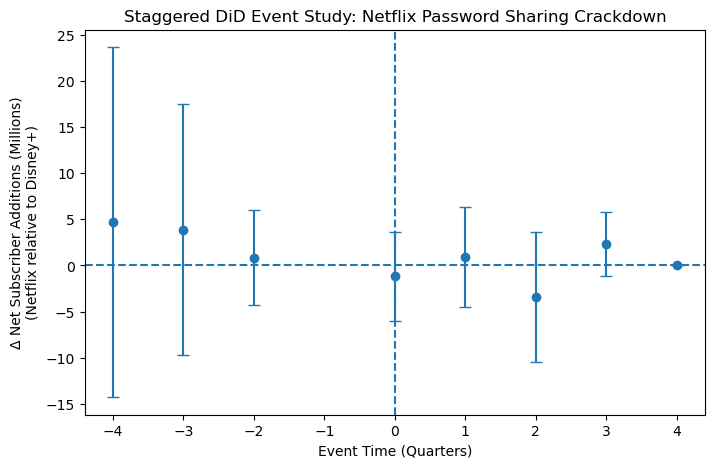

In [45]:
plt.figure(figsize=(8, 5))

plt.errorbar(
    times,
    coefs,
    yerr=[np.array(coefs) - np.array(lower), np.array(upper) - np.array(coefs)],
    fmt="o",
    capsize=4,
)

plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")

plt.xlabel("Event Time (Quarters)")
plt.ylabel("Δ Net Subscriber Additions (Millions)\n(Netflix relative to Disney+)")
plt.title("Staggered DiD Event Study: Netflix Password Sharing Crackdown")

plt.show()

A key limitation of the analysis is data availability. 
While Netflix provides detailed region-level metrics in its earnings filings, 
Disney+ disclosures are more limited and less granular. In particular, consistent 
region-level subscriber and revenue data are not publicly available, requiring 
the use of proxy or reconstructed measures for comparison.

This limitation directly affects interpretation. The reduced comparability and 
smaller sample size introduce additional noise into the estimates, leading to 
wider confidence intervals and lower statistical precision. As a result, while 
the estimated effects are generally directionally positive, they are not 
statistically significant in the regional specification.

Taken together, the results suggest that the password-sharing crackdown 
likely contributed to subscriber growth, but the magnitude of the effect is 
uncertain, and findings should be interpreted cautiously given data constraints.

NameError: name 'df' is not defined

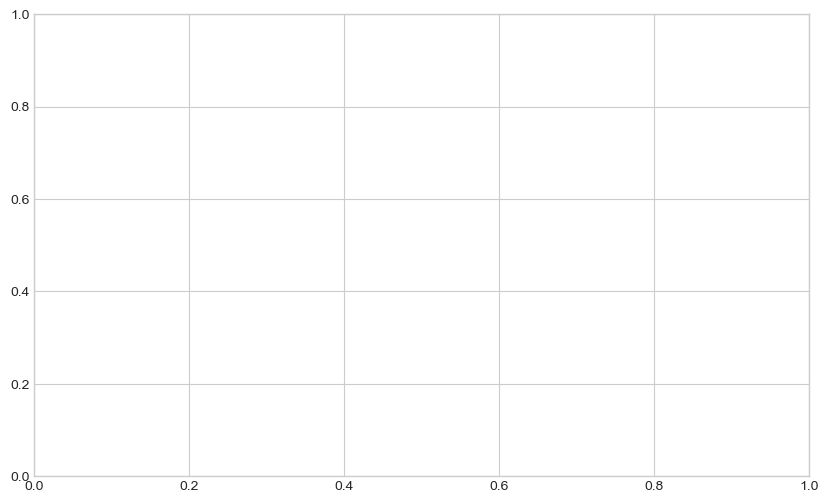

In [52]:
# --- Colors ---
RED = "#E50914"
GRAY = "#6B7280"
DARK = "#111827"
LIGHT_GRAY = "#E5E7EB"

REGION_COLORS = {
    "UCAN": RED,
    "EMEA": "#374151",
    "LATAM": "#B91C1C",
    "APAC": "#6B7280"
}

plt.style.use("seaborn-v0_8-whitegrid")

fig, ax = plt.subplots(figsize=(10, 6))

# -----------------------------
# ASSUMPTION: df has:
# columns = ["date", "region", "net_adds"]
# -----------------------------

# Sort data
df = df.sort_values(["region", "date"])

# -----------------------------
# OPTION 1: If you already have standard errors
# df["se"]
# -----------------------------

# -----------------------------
# OPTION 2 (Fallback): Estimate SE via rolling std (proxy)
# -----------------------------
df["se"] = df.groupby("region")["net_adds"].transform(
    lambda x: x.rolling(3, min_periods=1).std()
)

# -----------------------------
# Plot each region
# -----------------------------
for region, d in df.groupby("region"):

    color = REGION_COLORS.get(region, DARK)

    x = d["date"]
    y = d["net_adds"]
    se = d["se"].fillna(0)

    # --- Line
    ax.plot(
        x,
        y,
        label=region,
        color=color,
        linewidth=2.5,
        marker="o",
        markersize=5,
        zorder=3
    )

    # --- Confidence band (95%)
    ax.fill_between(
        x,
        y - 1.96 * se,
        y + 1.96 * se,
        color=color,
        alpha=0.15,
        zorder=1
    )

# -----------------------------
# Labels
# -----------------------------
ax.set_title(
    "Netflix Net Paid Additions by Region",
    fontsize=14,
    weight="bold",
    color=DARK,
    pad=12
)

ax.set_xlabel("Date", fontsize=11, color=DARK)
ax.set_ylabel("Net Additions (Millions)", fontsize=11, color=DARK)

# -----------------------------
# Styling
# -----------------------------
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(axis='x', colors=GRAY)
ax.tick_params(axis='y', colors=GRAY)

# -----------------------------
# Legend
# -----------------------------
ax.legend(frameon=True, title="Region")

# -----------------------------
# Footnote (VERY important for professor)
# -----------------------------
plt.figtext(
    0.99,
    0.01,
    "Note: Shaded areas represent 95% confidence intervals. "
    "Standard errors approximated using rolling variation.",
    ha="right",
    fontsize=8,
    color=GRAY
)

plt.tight_layout()
plt.show()

In [ ]:
import statsmodels.formula.api as smf
import pandas as pd

print("\n" + "=" * 60)
print("ROBUSTNESS CHECKS — Regional Triple Difference")
print("=" * 60 + "\n")


# Make sure ddd_term exists
df_combined["ddd_term"] = df_combined["is_netflix"] * df_combined["treated"]


# ROBUSTNESS 1 — Alternative Treatment Timing
print("\nROBUSTNESS 1 — Alternative Treatment Timing")

alt_df = df_combined.copy()

# Shift timing by one quarter
alt_df["post_alt"] = (alt_df["date"] >= pd.Timestamp("2023-09-30")).astype(int)

# Interaction
alt_df["ddd_term_alt"] = alt_df["is_netflix"] * alt_df["post_alt"]

model_alt = smf.ols(
    "net_adds ~ ddd_term_alt + is_netflix + post_alt + C(date)", data=alt_df
).fit(cov_type="HC3")

print(
    "Alternative timing DDD coefficient:", model_alt.params["ddd_term_alt"], 
    "million"
)
print("p-value:", model_alt.pvalues["ddd_term_alt"])


# ROBUSTNESS 2 — Adding Policy Controls
print("\nROBUSTNESS 2 — Adding Policy Controls")

ctrl_df = df_combined.copy()

# Proxy controls (adjust if needed)
ctrl_df["ad_tier"] = (ctrl_df["date"] >= pd.Timestamp("2022-11-01")).astype(int)
ctrl_df["price_increase"] = (ctrl_df["date"] >= pd.Timestamp("2023-01-01")).astype(int)

model_ctrl = smf.ols(
    "net_adds ~ ddd_term + is_netflix + treated + ad_tier + price_increase + C(date)",
    data=ctrl_df,
).fit(cov_type="HC3")

print("With controls DDD coefficient:", model_ctrl.params["ddd_term"], "million")
print("p-value:", model_ctrl.pvalues["ddd_term"])


# ROBUSTNESS 3 — Excluding One Region
print("\nROBUSTNESS 3 — Excluding One Region")

no_emea_df = df_combined[df_combined["region"] != "EMEA"].copy()

model_no_emea = smf.ols(
    "net_adds ~ ddd_term + is_netflix + treated + C(date)", data=no_emea_df
).fit(cov_type="HC3")

print("Drop EMEA DDD coefficient:", model_no_emea.params["ddd_term"], "million")
print("p-value:", model_no_emea.pvalues["ddd_term"])


ROBUSTNESS CHECKS — Regional Triple Difference


ROBUSTNESS 1 — Alternative Treatment Timing
Alternative timing DDD coefficient: -0.7746666666666658 million
p-value: 0.7135310894855321

ROBUSTNESS 2 — Adding Policy Controls
With controls DDD coefficient: -0.5956585365853675 million
p-value: 0.5178185296281456

ROBUSTNESS 3 — Excluding One Region
Drop EMEA DDD coefficient: 0.16725000000000143 million
p-value: 0.9201671284853543
